# Phát triển bán hàng trên app mobile hay website

Tệp tin Ecommerce_Customers.csv có dữ liệu của khách hàng mua quần áo trực tuyến. Cửa hàng cung cấp
các buổi tư vấn về phong cách và quần áo tại cửa hàng. Khách hàng đến cửa hàng, gặp gỡ/làm việc với nhà
tạo mẫu cá nhân, sau đó họ có thể về nhà và đặt mua quần áo họ muốn trên ứng dụng di động hoặc trang
web.

Công ty đang cố gắng quyết định xem nên tập trung nỗ lực vào trải nghiệm ứng dụng di động hay trang web
của họ.

Dữ liệu bao gồm một số thông tin của khoảng 500 khách hàng:

- Email: địa chỉ email duy nhất xác định mỗi khách hàng.

- Address: địa chỉ của khách hàng.

- Avg. Session Length: trung bình thời gian tương tác.

- Time on App: thời gian tương tác trên mobile app.

- Time on Website: thời gian tương tác trên website.

- Length of Membership: thời gian là khách hàng thành viên.

- Yearly Amount Spent: chi phí mua hàng trung bình năm.

## Load  dữ liệu

In [7]:
import pandas as pd

# Đọc file CSV
data = pd.read_csv("/content/Ecommerce_Customers.csv")

# Chuyển tên các cột về chữ thường
data.columns = (
    data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
)

print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   email                 500 non-null    object 
 1   address               500 non-null    object 
 2   avatar                500 non-null    object 
 3   avg_session_length    500 non-null    float64
 4   time_on_app           500 non-null    float64
 5   time_on_website       500 non-null    float64
 6   length_of_membership  500 non-null    float64
 7   yearly_amount_spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
None
                           email  \
0      mstephenson@fernandez.com   
1              hduke@hotmail.com   
2               pallen@yahoo.com   
3        riverarebecca@gmail.com   
4  mstephens@davidson-herman.com   

                                             address            avatar  \
0       835 Frank Tunnel\nWrightmouth

## Sau khi load dữ liệu thực hiện một bản báo cáo cho nhà quản lý và phát triển của công ty, với các nội dung như sau:

### 1. Bảng tóm tắt, khái quát về dữ liệu.


* Xóa các cột không cần thiết:

In [9]:
data = data.drop(columns=["email", "address", "avatar"])

print(data.head())

   avg_session_length  time_on_app  time_on_website  length_of_membership  \
0           34.497268    12.655651        39.577668              4.082621   
1           31.926272    11.109461        37.268959              2.664034   
2           33.000915    11.330278        37.110597              4.104543   
3           34.305557    13.717514        36.721283              3.120179   
4           33.330673    12.795189        37.536653              4.446308   

   yearly_amount_spent  
0           587.951054  
1           392.204933  
2           487.547505  
3           581.852344  
4           599.406092  


* Kiểm tra data có bị thiếu giá trị không:

In [17]:
data.isna().sum()

,0
avg_session_length,0
time_on_app,0
time_on_website,0
length_of_membership,0
yearly_amount_spent,0


* Bảng tóm tắt và khái quát về dữ liệu:

In [18]:
cols = [
    "avg_session_length",
    "time_on_app",
    "time_on_website",
    "length_of_membership",
    "yearly_amount_spent"
]

summary_table = (
    data[cols]
    .agg(["count", "mean", "median", "min", "max"])
    .T
    .reset_index()
)

summary_table.columns = ["Biến", "Số lượng", "Trung bình", "Trung vị", "Min", "Max"]

summary_table

,Biến,Số lượng,Trung bình,Trung vị,Min,Max
0,avg_session_length,500.0,33.053194,33.082008,29.532429,36.139662
1,time_on_app,500.0,12.052488,11.983231,8.508152,15.126994
2,time_on_website,500.0,37.060445,37.069367,33.913847,40.005182
3,length_of_membership,500.0,3.533462,3.533975,0.269901,6.922689
4,yearly_amount_spent,500.0,499.314038,498.887875,256.670582,765.518462


Nhận xét: Trung bình và trung vị gần nhau, chứng tỏ phân phối khá cân đối. Khoảng giá trị min, max khá hẹp (ngoại trừ cột yearly_amount_spent) do đó không xuất hiện giá trị ngoại lai (outliers).

* Kiểm tra giá trị ngoại lai outlier của cột yearly_amount_spent:

In [19]:
col = "yearly_amount_spent"

Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1

data = data[
    data[col].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
]

* Bảng tóm tắt và khái quát về dữ liệu sau khi kiểm tra và xử lí giá trị ngoại lai (outliers) của cột yearly_amount_spent:

In [20]:
cols = [
    "avg_session_length",
    "time_on_app",
    "time_on_website",
    "length_of_membership",
    "yearly_amount_spent"
]

summary_table = (
    data[cols]
    .agg(["count", "mean", "median", "min", "max"])
    .T
    .reset_index()
)

summary_table.columns = ["Biến", "Số lượng", "Trung bình", "Trung vị", "Min", "Max"]

summary_table

,Biến,Số lượng,Trung bình,Trung vị,Min,Max
0,avg_session_length,491.0,33.053659,33.078717,29.532429,36.139662
1,time_on_app,491.0,12.044779,11.982045,8.508152,14.715388
2,time_on_website,491.0,37.065886,37.071643,34.476878,40.005182
3,length_of_membership,491.0,3.529321,3.532862,0.269901,6.401229
4,yearly_amount_spent,491.0,498.817140,498.635599,298.762008,700.917092


* Heatmap mối tương quan giữa các biến:

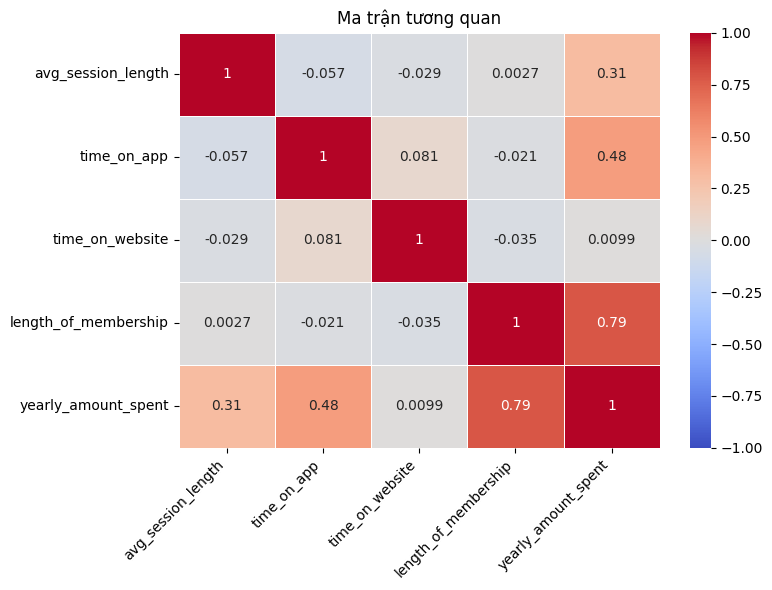

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Chọn các cột số
numeric_data = data.select_dtypes(include=np.number)

# Tính ma trận tương quan
cor_matrix = numeric_data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    cor_matrix,
    annot=True,
    cmap="coolwarm",      # tương đương blue → white → red
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title("Ma trận tương quan")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Nhận xét: yearly_amount_spent có mối tương quan cao nhất với length_of_membership, thể hiện qua màu đỏ đậm (hệ số tương quan dương lớn). Điều này cho thấy thời gian là thành viên càng lâu, khách hàng càng chi tiêu nhiều hơn hàng năm. yearly_amount_spent cũng có tương quan tích cực nhưng thấp hơn với time_on_app và avg_session_length. Mối tương quan giữa yearly_amount_spent và time_on_website là khá yếu, gần như không đáng kể.

### 2. Thời gian tương tác trên 2 nền tảng có khác biệt (có thể thử khai thác theo góc nhìn về thời gian là khách hàng thành viên)?

* Tương tác theo nhóm length_of_membership

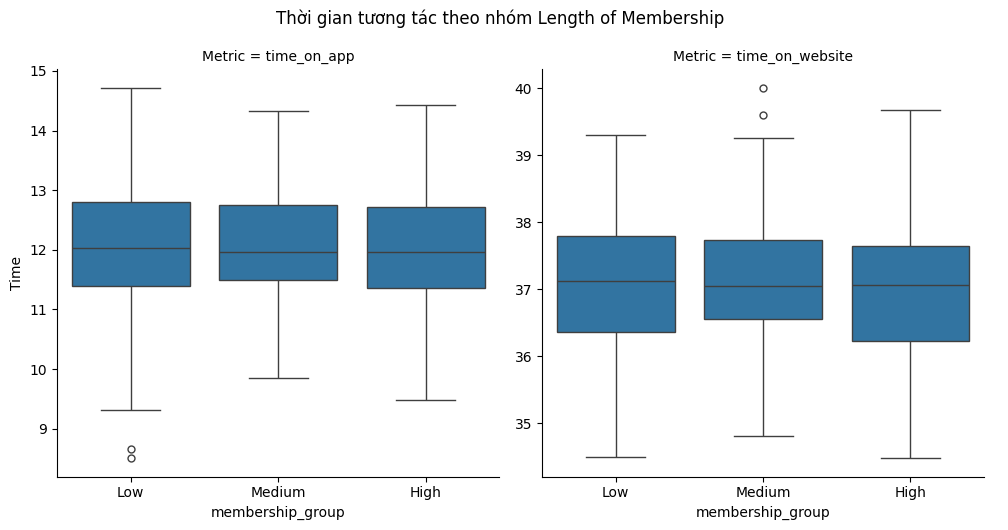

In [25]:
# Chia nhóm dựa trên phân vị
data["membership_group"] = pd.qcut(
    data["length_of_membership"],
    q=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"]
)

# Chuyển đổi dữ liệu để sử dụng facet
data_long = data.melt(
    id_vars="membership_group",
    value_vars=["time_on_app", "time_on_website"],
    var_name="Metric",
    value_name="Time"
)

# Tạo biểu đồ với facet_wrap
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=data_long,
    x="membership_group",
    y="Time",
    col="Metric",
    kind="box",
    sharey=False
)

g.fig.suptitle("Thời gian tương tác theo nhóm Length of Membership", y=1.05)

plt.show()

Nhận xét: Dựa vào biểu đồ boxplot trên, ta thấy rằng thời gian tương tác trên ứng dụng (time_on_app) và thời gian tương tác trên website (time_on_website) có một số khác biệt. Nhóm Length of Membership có thời gian tương tác trên ứng dụng (khoảng 11-13 đơn vị) thấp hơn đáng kể so với thời gian tương tác trên website (khoảng 36-38 đơn vị). Vì vậy, có thể nói rằng thời gian tương tác của các Nhóm Length of Membership có sự khác biệt giữa ứng dụng và website.

### 3. Lựa chọn biến Y để xây dựng mô hình cho thấy nên đầu tư vào nền tảng mobile app hay website.

Lựa chọn biến Y là yearly_amount_spent để xây dựng mô hình cho thấy nên đầu tư vào nền tảng mobile app hay website.

In [27]:
from sklearn.linear_model import LinearRegression

X = data[[
    "avg_session_length",
    "time_on_app",
    "time_on_website",
    "length_of_membership"
]]

y = data["yearly_amount_spent"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R^2:", model.score(X, y))

Intercept: -1045.5744198127231
Coefficients: [25.60579155 38.67768656  0.41264467 61.44730076]
R^2: 0.9817291217301997


* Áp dụng phương pháp bootstrap để ước lượng khoảng tin cậy và kiểm định giả thuyết βj = 0

In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Đặt seed giống set.seed(84)
np.random.seed(84)

# Biến độc lập và phụ thuộc
X = data[[
    "avg_session_length",
    "time_on_app",
    "time_on_website",
    "length_of_membership"
]]
y = data["yearly_amount_spent"]

# Thêm intercept
X = sm.add_constant(X)

# Số lần bootstrap
R = 1000
n = len(data)

# Lưu hệ số
boot_coefs = []

for _ in range(R):
    sample_idx = np.random.choice(n, n, replace=True)
    X_sample = X.iloc[sample_idx]
    y_sample = y.iloc[sample_idx]

    model = sm.OLS(y_sample, X_sample).fit()
    boot_coefs.append(model.params.values)

boot_coefs = np.array(boot_coefs)

# Chuyển thành DataFrame cho dễ đọc
coef_names = X.columns
boot_df = pd.DataFrame(boot_coefs, columns=coef_names)

boot_df.head()

,const,avg_session_length,time_on_app,time_on_website,length_of_membership
0,-1005.035238,24.726072,37.613494,0.430511,61.425418
1,-1047.554858,25.806567,39.395534,0.068333,61.316638
2,-1078.678167,26.443726,38.364189,0.809447,60.161201
3,-1008.821466,25.140163,38.480119,-0.138585,61.839677
4,-1034.278779,25.676692,38.767292,0.045153,61.023169


* Khoảng tin cậy 95%:

In [31]:
ci_lower = boot_df.quantile(0.025)
ci_upper = boot_df.quantile(0.975)

ci_table = pd.DataFrame({
    "CI Lower (2.5%)": ci_lower,
    "CI Upper (97.5%)": ci_upper
})

ci_table

,CI Lower (2.5%),CI Upper (97.5%)
const,-1089.605626,-1001.413318
avg_session_length,24.717377,26.520012
time_on_app,37.760623,39.534969
time_on_website,-0.432548,1.270829
length_of_membership,60.488865,62.249515


* Bootstrap p-value

In [32]:
pvals = []

for col in boot_df.columns:
    qt0 = np.mean(boot_df[col] <= 0)

    if qt0 < 0.5:
        pval = 2 * qt0
    else:
        pval = 2 * (1 - qt0)

    pvals.append(pval)

pval_table = pd.Series(pvals, index=boot_df.columns)
pval_table

,0
const,0.000
avg_session_length,0.000
time_on_app,0.000
time_on_website,0.318
length_of_membership,0.000


Nhận xét: Từ đây ta thấy, p-value của time_on_website = 0.318 > 0.05. Do vậy, nó không có ý nghĩa thống kê, tức là nó không có ảnh hưởng gì tới mô hình. Để chắc chắn thêm, ta sẽ dùng biểu đồ để thể hiện sự tương án giữa biến time_on_website và yearly_amount_spent và phương pháp dùng tập con tốt nhất cross vadation.

In [37]:
import numpy as np
import seaborn as sns

# Lấy hệ số
beta_j = model.params["time_on_website"]

# Residual thường
residuals = model.resid

# Partial residual
partial_resid = residuals + beta_j * data["time_on_website"]

# Term (giống predict(type="terms"))
terms = beta_j * data["time_on_website"]

# DataFrame mới
df_part = pd.DataFrame({
    "time_on_website": data["time_on_website"],
    "partial_resid_time_on_website": partial_resid,
    "terms_time_on_website": terms
})

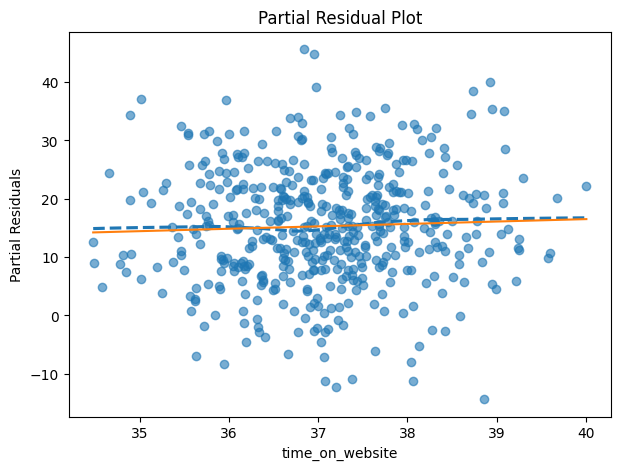

In [38]:
plt.figure(figsize=(7,5))

# Scatter
plt.scatter(
    df_part["time_on_website"],
    df_part["partial_resid_time_on_website"],
    alpha=0.6
)

# LOESS smooth
sns.regplot(
    data=df_part,
    x="time_on_website",
    y="partial_resid_time_on_website",
    lowess=True,
    scatter=False,
    line_kws={"linestyle": "dashed"}
)

# Đường linear term
sorted_idx = np.argsort(df_part["time_on_website"])
plt.plot(
    df_part["time_on_website"].iloc[sorted_idx],
    df_part["terms_time_on_website"].iloc[sorted_idx]
)

plt.xlabel("time_on_website")
plt.ylabel("Partial Residuals")
plt.title("Partial Residual Plot")
plt.show()

Nhận xét: ta thấy, time_on_website không có sự tương quan giữa yearly_amount_spent.

In [39]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

np.random.seed(123)

features = [
    "avg_session_length",
    "time_on_app",
    "time_on_website",
    "length_of_membership"
]

X = data[features]
y = data["yearly_amount_spent"]

In [40]:
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=123)

In [41]:
cv_results = {}

for num_vars in range(1, len(features) + 1):

    best_rmse = np.inf
    best_subset = None

    for subset in combinations(features, num_vars):

        rmse_folds = []

        for train_idx, test_idx in kf.split(X):

            X_train = X.iloc[train_idx][list(subset)]
            X_test = X.iloc[test_idx][list(subset)]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            model = LinearRegression()
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            rmse = np.sqrt(mean_squared_error(y_test, preds))
            rmse_folds.append(rmse)

        mean_rmse = np.mean(rmse_folds)

        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_subset = subset

    cv_results[num_vars] = (best_subset, best_rmse)

In [42]:
for k_vars, (subset, rmse) in cv_results.items():
    print(f"{k_vars} biến: {subset} | RMSE = {rmse:.4f}")

1 biến: ('length_of_membership',) | RMSE = 45.3805
2 biến: ('time_on_app', 'length_of_membership') | RMSE = 26.9691
3 biến: ('avg_session_length', 'time_on_app', 'length_of_membership') | RMSE = 9.9821
4 biến: ('avg_session_length', 'time_on_app', 'time_on_website', 'length_of_membership') | RMSE = 9.9881


In [43]:
best_model = min(cv_results.items(), key=lambda x: x[1][1])

print("\nModel tốt nhất có", best_model[0], "biến")
print("RMSE =", round(best_model[1][1], 4))
print("Biến được chọn:", best_model[1][0])


Model tốt nhất có 3 biến
RMSE = 9.9821
Biến được chọn: ('avg_session_length', 'time_on_app', 'length_of_membership')


* Chuẩn đoán mô hình:

In [44]:
import statsmodels.api as sm

features = [
    "avg_session_length",
    "time_on_app",
    "length_of_membership"
]

X = data[features]
y = data["yearly_amount_spent"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     yearly_amount_spent   R-squared:                       0.982
Model:                             OLS   Adj. R-squared:                  0.982
Method:                  Least Squares   F-statistic:                     8707.
Date:                 Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                         07:09:40   Log-Likelihood:                -1824.9
No. Observations:                  491   AIC:                             3658.
Df Residuals:                      487   BIC:                             3675.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -

* Xét sự đồng nhất phương sai

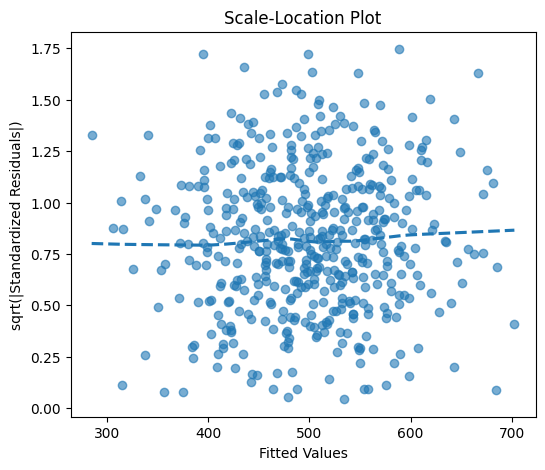

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fitted values
fitted = model.fittedvalues

# Standardized residuals
influence = model.get_influence()
std_resid = influence.resid_studentized_internal

# Plot
plt.figure(figsize=(6,5))

plt.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.6)

sns.regplot(
    x=fitted,
    y=np.sqrt(np.abs(std_resid)),
    lowess=True,
    scatter=False,
    line_kws={"linestyle": "dashed"}
)

plt.xlabel("Fitted Values")
plt.ylabel("sqrt(|Standardized Residuals|)")
plt.title("Scale-Location Plot")
plt.show()

Nhận xét: Dựa vào biểu đồ trên, ta thấy có sự đồng nhất phương sai.

* Sự tuyến tính của từng biến đối với biến mục tiêu yearly_amount_spent:

In [46]:
def partial_residual_plot(model, data, feature):

    beta_j = model.params[feature]
    residuals = model.resid

    partial_resid = residuals + beta_j * data[feature]
    terms = beta_j * data[feature]

    plt.figure(figsize=(6,5))

    plt.scatter(data[feature], partial_resid, alpha=0.6)

    sns.regplot(
        x=data[feature],
        y=partial_resid,
        lowess=True,
        scatter=False,
        line_kws={"linestyle": "dashed"}
    )

    sorted_idx = np.argsort(data[feature])
    plt.plot(
        data[feature].iloc[sorted_idx],
        terms.iloc[sorted_idx]
    )

    plt.xlabel(feature)
    plt.ylabel("Partial Residuals")
    plt.title(f"Partial Residual Plot: {feature}")
    plt.show()

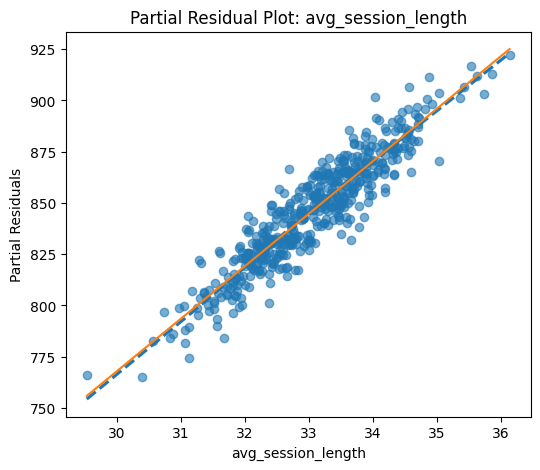

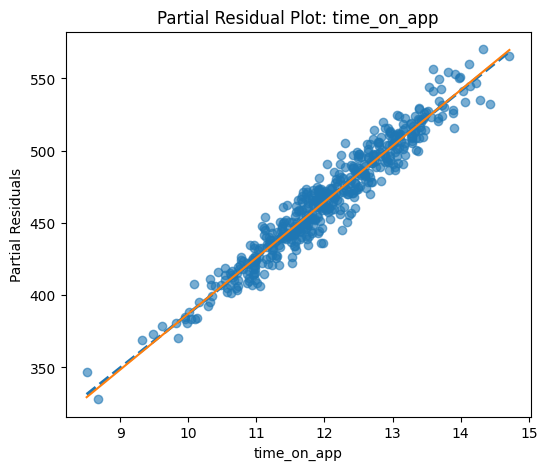

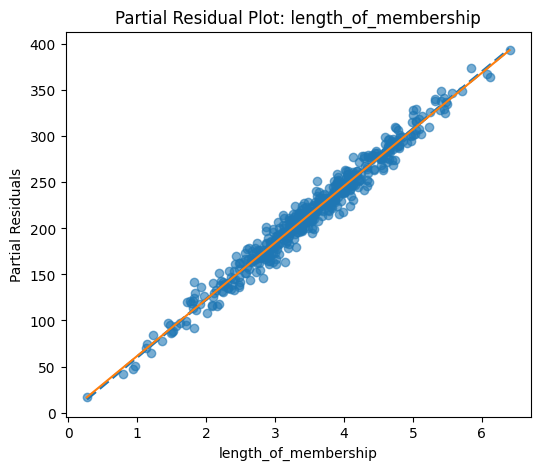

In [47]:
partial_residual_plot(model, data, "avg_session_length")
partial_residual_plot(model, data, "time_on_app")
partial_residual_plot(model, data, "length_of_membership")

Nhận xét: Dựa vào 3 biểu đồ trên, ta thấy cả 3 biến đều có sự tuyến tính với biến mục tiêu yearly_amount_spent.

* Vậy ta sẽ bỏ cột time_on_website khỏi data:

In [48]:
data = data.drop(columns=["time_on_website"])

* Xét các giá trị ngoại lai

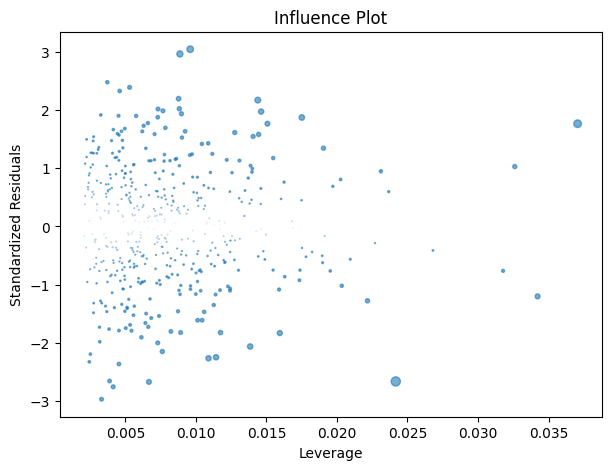

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Fit model 3 biến
features = [
    "avg_session_length",
    "time_on_app",
    "length_of_membership"
]

X = sm.add_constant(data[features])
y = data["yearly_amount_spent"]

model = sm.OLS(y, X).fit()

# Influence measures
influence = model.get_influence()

std_resid = influence.resid_studentized_internal
hat_values = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

# Bubble plot
plt.figure(figsize=(7,5))

plt.scatter(
    hat_values,
    std_resid,
    s=1000*cooks_d,   # size theo Cook's D
    alpha=0.6
)

plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Influence Plot")
plt.show()

In [52]:
data_cooks = pd.DataFrame({
    "id_point": np.arange(len(data)),
    "rstand": std_resid,
    "hats": hat_values,
    "cooks": cooks_d,
    "sales": data["yearly_amount_spent"]
})

# Sắp xếp theo Cook's Distance giảm dần
data_cooks_sorted = data_cooks.sort_values("cooks", ascending=False)

data_cooks_sorted.head()

,id_point,rstand,hats,cooks,sales
260,255,-2.664458,0.024170,0.043959,640.187740
309,302,1.767137,0.037064,0.030050,302.189548
460,451,3.047781,0.009594,0.022496,618.845970
148,146,2.966839,0.008863,0.019678,424.185494
244,239,2.172222,0.014385,0.017217,591.781089


In [53]:
# Lọc các điểm ngoại lai dựa trên ngưỡng
outliers = data_cooks[
    (np.abs(data_cooks["rstand"]) > 2) |
    (data_cooks["cooks"] > 0.5)
]

print(outliers)

     id_point    rstand      hats     cooks       sales
75         73  2.329283  0.004592  0.006257  478.719357
82         80 -2.266424  0.010891  0.014140  596.430173
96         94 -2.657501  0.003878  0.006873  521.142952
120       118  2.197570  0.008770  0.010682  576.311177
148       146  2.966839  0.008863  0.019678  424.185494
160       157 -2.327672  0.002438  0.003311  468.913501
166       163  2.480290  0.003714  0.005734  497.811930
169       166 -2.150053  0.007617  0.008871  501.749233
244       239  2.172222  0.014385  0.017217  591.781089
260       255 -2.664458  0.024170  0.043959  640.187740
278       273  2.024717  0.008824  0.009124  530.362469
378       370 -2.194852  0.002517  0.003039  486.163799
386       378  2.019945  0.007310  0.007511  550.813368
389       381 -2.001169  0.007294  0.007356  581.308933
399       391 -2.757435  0.004133  0.007889  408.216902
412       404 -2.365701  0.004539  0.006380  444.053827
418       409 -2.672985  0.006668  0.011991  475

In [54]:
# Trích xuất các điểm ngoại lai từ dữ liệu gốc
data_outliers = data.iloc[outliers["id_point"]]

print(data_outliers)

     avg_session_length  time_on_app  length_of_membership  \
75            32.049839    12.238057              3.120569   
82            33.501370    13.898082              4.130563   
96            33.790387    11.942341              4.081803   
120           34.569381    12.854990              3.292798   
148           32.692392    12.296518              1.825885   
160           32.838100    12.364342              3.309182   
166           33.630801    12.039648              2.873008   
169           32.654622    11.052324              4.717103   
244           31.283447    12.725677              5.000243   
260           35.039283    14.426491              3.930615   
278           32.607903    13.677246              2.871948   
378           32.784940    12.451200              3.535802   
386           33.208920    13.531913              3.046541   
389           34.195508    12.664193              4.330407   
399           32.377990    11.971751              2.829700   
412     

* Tiên đoán dựa trên mô hình:

In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# Đặt seed
np.random.seed(123)

features = [
    "avg_session_length",
    "time_on_app",
    "length_of_membership"
]

X = data[features]
y = data["yearly_amount_spent"]

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=123
)

# Thêm intercept
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

In [56]:
# Fit OLS trên Train
model = sm.OLS(y_train, X_train_sm).fit()

In [59]:
# Predict trên Test
test_predictions = model.predict(X_test_sm)

In [60]:
# Sai số
test_errors = y_test - test_predictions

# MSE
MSE_test = np.mean(test_errors**2)

# RMSE
RMSE_test = np.sqrt(MSE_test)

# RSS
RSS_test = np.sum(test_errors**2)

# n và p
n_test = len(y_test)
p = X_train.shape[1]   # số biến độc lập (không tính intercept)

# RSE
RSE_test = np.sqrt(RSS_test / (n_test - p - 1))

# R2
TSS_test = np.sum((y_test - np.mean(y_test))**2)
R2_test = 1 - (RSS_test / TSS_test)

print("MSE (Test):", MSE_test)
print("RMSE (Test):", RMSE_test)
print("R^2 (Test):", R2_test)
print("RSE (Test):", RSE_test)

MSE (Test): 82.99824322982226
RMSE (Test): 9.110337163344848
R^2 (Test): 0.9834384658647377
RSE (Test): 9.236002922596237


Nhận xét: Ta thấy RMSE và RSE gần bằng nhau và  R^2 khá cao (~ 0.98). Do đó, mô hình của ta khá tốt.

In [63]:
pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.2 MB/s eta 0:00:00


In [64]:
import numpy as np
import pandas as pd
from pygam import LinearGAM, s, l
import matplotlib.pyplot as plt

In [65]:
features = [
    "time_on_app",
    "length_of_membership",
    "avg_session_length"
]

X = data[features].values
y = data["yearly_amount_spent"].values

In [66]:
gam = LinearGAM(
    s(0, n_splines=5) +   # spline cho time_on_app
    l(1) +                # linear length_of_membership
    l(2)                  # linear avg_session_length
).fit(X, y)

print(gam.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.7896
Link Function:                     IdentityLink Log Likelihood:                                 -1824.7572
Number of Samples:                          491 AIC:                                             3661.0936
                                                AICc:                                             3661.256
                                                GCV:                                              101.7375
                                                Scale:                                              9.9976
                                                Pseudo R-Squared:                                   0.9817
Feature Function                  Lam

/tmp/ipykernel_849/3422455493.py:7: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [67]:
terms = gam.partial_dependence(term=0, X=X)

In [68]:
residuals = y - gam.predict(X)

partial_residual_toa = residuals + gam.partial_dependence(term=0, X=X)

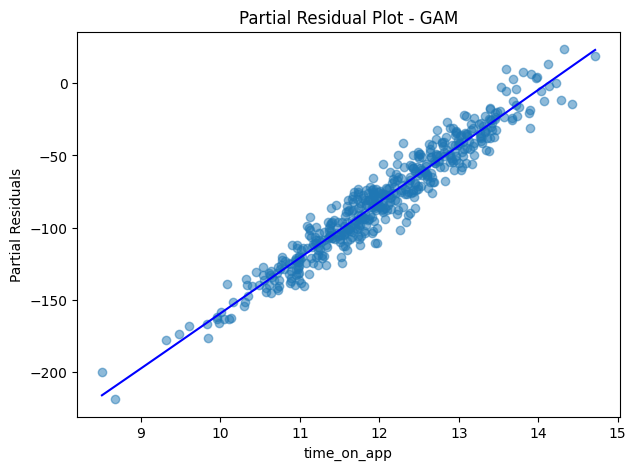

In [69]:
plt.figure(figsize=(7,5))

# Scatter partial residual
plt.scatter(
    data["time_on_app"],
    partial_residual_toa,
    alpha=0.5
)

# Đường spline ước lượng
grid = gam.generate_X_grid(term=0)
plt.plot(
    grid[:, 0],
    gam.partial_dependence(term=0, X=grid),
    color="blue"
)

plt.xlabel("time_on_app")
plt.ylabel("Partial Residuals")
plt.title("Partial Residual Plot - GAM")
plt.show()

In [75]:
from sklearn.metrics import r2_score

r2_gam = r2_score(y, gam.predict(X))
print("R2 GAM:", r2_gam)

R2 GAM: 0.981712317919256


Nhận xét: R^2 không có thay đổi nhiều nên chúng ta không cần mở rộng mô hình.

### 4. Viết các nhận xét và kết luận:

Kết luận:

- Nền tảng nên đầu tư: time_on_app có hệ số hồi quy cao và ý nghĩa thống kê mạnh, trong khi time_on_website không có ý nghĩa thống kê. Do đó, công ty nên tập trung đầu tư vào ứng dụng di động để tăng chi tiêu trung bình của khách hàng.

- Chiến lược giữ chân khách hàng: length_of_membership có tác động mạnh đến chi tiêu. Công ty nên đầu tư vào các chương trình khách hàng thân thiết để kéo dài thời gian là thành viên.

- Hạn chế: Thời gian tương tác trên website có vẻ không có ảnh hưởng lớn, nhưng cần kiểm tra thêm các yếu tố khác như chất lượng trải nghiệm hoặc chức năng cụ thể của website.

- Khuyến khích cải thiện: Cải thiện giao diện người dùng và tính năng trên ứng dụng di động. Xây dựng chương trình ưu đãi hoặc giảm giá để khuyến khích khách hàng sử dụng ứng dụng nhiều hơn.